In [1]:
import collections, sys, warnings
from pathlib import Path

import numpy as np
import onnx
import onnxruntime as ort
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.set_printoptions(precision=6, suppress=True, linewidth=120)

# Walk up to the repo root, so the notebook works from wherever it is opened.
REPO = Path.cwd()
while not (REPO / 'data_fp32').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
assert (REPO / 'data_fp32').is_dir(), 'could not locate the repo root (no data_fp32/)'

DATA   = REPO / 'data_fp32'          # float32 weights. NEVER data/, that one is int16.
BATCHD = REPO / 'aieml_batch'
SIMOUT = BATCHD / 'results' / 'sim_events'
TESTD  = REPO / 'testdata'
OUTD   = BATCHD / 'notebooks' / 'out'
OUTD.mkdir(parents=True, exist_ok=True)

# Geometry - must match the compiled graph (src/parameters.h, kernels/track_accum.h)
H                = 128    # HIDDEN_SIZE
TRACKS_PER_EVENT = 50     # TA_EVENT
SLOTS_PER_EVENT  = 56     # 7 iterations x BATCH 8
BATCH            = 8
OUT_DIM          = 27
REAL_FEATURES    = 6      # physically meaningful inputs; the files carry 8
WARMUP           = 3      # receptive field is 4 tracks deep -> first 3 are contaminated

print('repo   :', REPO)
print('weights:', DATA)
print('sim out:', SIMOUT, '' if SIMOUT.is_dir() else '  (MISSING - run make x86_events)')
print('numpy', np.__version__, '| onnx', onnx.__version__, '| onnxruntime', ort.__version__)


repo   : /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo
weights: /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/data_fp32
sim out: /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/aieml_batch/results/sim_events 
numpy 2.2.6 | onnx 1.19.0 | onnxruntime 1.22.1


In [2]:
ONNX_PATH = REPO / 'punit/onnx_no-residual/onnx_files_narrow/mlp_fp32.onnx'
assert ONNX_PATH.exists(), ONNX_PATH

def load_txt(name):
    return np.loadtxt(DATA / name).astype(np.float32)

def load_parts(stem, n, rows, cols):
    a = np.concatenate([load_txt(f'{stem}_part{i}.txt') for i in range(n)])
    return a.reshape(rows, cols).astype(np.float32)

# Every dense layer's weights, exactly as gen_graph.py assembles them for the AIE.
W = {'emb_d0': load_txt('embed_dense_0_weights.txt').reshape(8, H)[:REAL_FEATURES],
     'emb_d1': load_parts('embed_dense_1_weights', 2, H, H)}
B = {'emb_d0': load_txt('embed_dense_0_bias.txt'),
     'emb_d1': load_txt('embed_dense_1_bias.txt')}
for s in range(3):
    W[f's{s}_d0'] = load_parts(f'solver_{s}_dense_0_weights', 4, 2 * H, H)
    B[f's{s}_d0'] = load_txt(f'solver_{s}_dense_0_bias.txt')
    for d in (1, 2, 3):
        W[f's{s}_d{d}'] = load_parts(f'solver_{s}_dense_{d}_weights', 2, H, H)
        B[f's{s}_d{d}'] = load_txt(f'solver_{s}_dense_{d}_bias.txt')
W['output'] = load_txt('output_weights.txt').reshape(H, OUT_DIM)
B['output'] = load_txt('output_bias.txt')

model = onnx.load(ONNX_PATH)
inits = {i.name: onnx.numpy_helper.to_array(i) for i in model.graph.initializer}

print(ONNX_PATH.relative_to(REPO), '\n')
rows = []
for name, ref in W.items():
    best = (np.inf, None)
    for iname, arr in inits.items():
        if arr.ndim != 2 or arr.size != ref.size:
            continue
        for cand in (arr, arr.T):
            if cand.shape == ref.shape:
                best = min(best, (float(np.abs(cand.astype(np.float32) - ref).max()), iname))
    rows.append((name, ref.shape, best[0], best[1]))

worst = max(r[2] for r in rows)
for name, shape, d, iname in rows:
    print(f'  {name:9s} {str(shape):11s} max|diff| = {d:.3e}   <- {iname}')
print(f'\nworst over all {len(rows)} weight matrices: {worst:.3e}')
assert worst < 1e-6, 'this ONNX is a DIFFERENT checkpoint - do not use it as the reference'
print('MATCH: this ONNX carries the same weights the AIE was loaded with.')


punit/onnx_no-residual/onnx_files_narrow/mlp_fp32.onnx 

  emb_d0    (6, 128)    max|diff| = 7.451e-09   <- onnx::MatMul_147
  emb_d1    (128, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_148
  s0_d0     (256, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_161
  s0_d1     (128, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_162
  s0_d2     (128, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_163
  s0_d3     (128, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_164
  s1_d0     (256, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_177
  s1_d1     (128, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_178
  s1_d2     (128, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_179
  s1_d3     (128, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_180
  s2_d0     (256, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_193
  s2_d1     (128, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_194
  s2_d2     (128, 128)  max|diff| = 7.451e-09   <- onnx::MatMul_195
  s2_d3     (128, 128)  max|diff| = 7.451e-09   <- onnx::Ma

In [3]:
g = model.graph
shp = lambda v: [d.dim_value or d.dim_param for d in v.type.tensor_type.shape.dim]
print('inputs  :', [(v.name, shp(v)) for v in g.input])
print('outputs :', [(v.name, shp(v)) for v in g.output])
print('ops     :', dict(collections.Counter(n.op_type for n in g.node)))

rm = next(n for n in g.node if n.op_type == 'ReduceMean')
PER_TRACK_T = rm.input[0]     # (batch, 50, 128) - every track's final activation
MEAN_T      = rm.output[0]    # (batch, 128)     - what the AIE emits as track_out
print('\nper-track tensor :', PER_TRACK_T)
print('event-mean tensor:', MEAN_T)


inputs  : [('input', ['batch_size', 50, 6])]
outputs : [('output', ['batch_size', 27])]
ops     : {'MatMul': 14, 'Add': 14, 'LeakyRelu': 14, 'Constant': 36, 'Slice': 9, 'Concat': 9, 'ReduceMean': 1, 'Gemm': 1}

per-track tensor : /solvers.2/model/model.5/activ/LeakyRelu_output_0
event-mean tensor: /ReduceMean_output_0


In [4]:
def make_session(path, extra_outputs=()):
    m = onnx.load(path)
    have = {v.name for v in m.graph.output}
    for t in extra_outputs:
        if t not in have:
            m.graph.output.append(onnx.helper.ValueInfoProto(name=t))
    return ort.InferenceSession(m.SerializeToString(), providers=['CPUExecutionProvider'])

SESS = make_session(ONNX_PATH, (PER_TRACK_T, MEAN_T))
OUT_NAMES = [o.name for o in SESS.get_outputs()]
print('session outputs:', OUT_NAMES)

def run_onnx(tracks6, chunk=64):
    # tracks6: (n_events, 50, 6) -> dict with per_track / mean / out27.
    # Chunked so a 200-event run does not allocate one huge activation tensor.
    tracks6 = np.asarray(tracks6, dtype=np.float32)
    acc = collections.defaultdict(list)
    for i in range(0, len(tracks6), chunk):
        res = dict(zip(OUT_NAMES, SESS.run(OUT_NAMES, {'input': tracks6[i:i + chunk]})))
        acc['per_track'].append(res[PER_TRACK_T])
        acc['mean'].append(res[MEAN_T])
        acc['out27'].append(res['output'])
    return {k: np.concatenate(v).astype(np.float64) for k, v in acc.items()}


session outputs: ['output', '/solvers.2/model/model.5/activ/LeakyRelu_output_0', '/ReduceMean_output_0']


In [5]:
sys.path.insert(0, str(BATCHD))
import crosscheck as C     # numpy-only; an independent golden

X8  = load_txt('embed_input.txt').reshape(-1, 8)
x50 = X8[:TRACKS_PER_EVENT, :REAL_FEATURES][None, ...]        # (1, 50, 6)
r50 = run_onnx(x50)

emb_g, soln_g = C.golden()
np_per_track  = soln_g[2][:TRACKS_PER_EVENT]

print('ONNX per-track :', r50['per_track'].shape)
print('ONNX event mean:', r50['mean'].shape)
print('ONNX out27     :', r50['out27'].shape, '\n')

d_track = np.abs(r50['per_track'][0] - np_per_track).max()
d_mean  = np.abs(r50['mean'][0] - np_per_track.mean(0)).max()
d_out   = np.abs(r50['out27'][0] - (np_per_track.mean(0) @ W['output'] + B['output'])).max()
print(f'  [1] ONNX per-track  vs numpy golden : max|diff| = {d_track:.3e}')
print(f'  [2] ONNX event mean vs numpy golden : max|diff| = {d_mean:.3e}')
print(f'  [3] ONNX out27      vs numpy golden : max|diff| = {d_out:.3e}')

GATE = max(d_track, d_mean, d_out)
print(f'\n  worst = {GATE:.3e}   {"PASS" if GATE < 1e-6 else "FAIL"}')
assert GATE < 1e-6, 'the ONNX and the numpy golden disagree - resolve before continuing'


ONNX per-track : (1, 50, 128)
ONNX event mean: (1, 128)
ONNX out27     : (1, 27) 

  [1] ONNX per-track  vs numpy golden : max|diff| = 3.278e-07
  [2] ONNX event mean vs numpy golden : max|diff| = 2.235e-08
  [3] ONNX out27      vs numpy golden : max|diff| = 1.490e-08

  worst = 3.278e-07   PASS


In [6]:
# The aieml/ hardware dump. Different averaging convention, so a gap here is expected.
ref_hw = C.L('aieml10_output_aie.txt').reshape(-1, H)[:TRACKS_PER_EVENT]

print('vs the aieml/ VEK280 hardware dump (data_fp32/aieml10_output_aie.txt)\n')
print(f'  per-track, tracks {WARMUP}..49 : '
      f'{np.abs(r50["per_track"][0][WARMUP:] - ref_hw[WARMUP:]).max():.3e}   <- the real check')
print(f'  per-track, tracks 0..{WARMUP-1}        : '
      f'{np.abs(r50["per_track"][0][:WARMUP] - ref_hw[:WARMUP]).max():.3e}   <- warm-up, expected')
print(f'  event mean over all 50        : '
      f'{np.abs(r50["mean"][0] - ref_hw.mean(0)).max():.3e}')

print('\nThe warm-up gap is definitional, not error. The ONNX rolls CIRCULARLY inside a'
      '\n50-track event (track 0 pairs with track 49). A streaming implementation cannot do'
      '\nthat without buffering the whole event, so both aieml/ and aieml_batch pair track 0'
      '\nwith zero (or with the previous block). The receptive field is 4 tracks deep, so'
      '\ntracks 0..2 differ and 3..49 agree.')


vs the aieml/ VEK280 hardware dump (data_fp32/aieml10_output_aie.txt)

  per-track, tracks 3..49 : 1.058e-06   <- the real check
  per-track, tracks 0..2        : 2.118e-01   <- warm-up, expected
  event mean over all 50        : 4.768e-03

The warm-up gap is definitional, not error. The ONNX rolls CIRCULARLY inside a
50-track event (track 0 pairs with track 49). A streaming implementation cannot do
that without buffering the whole event, so both aieml/ and aieml_batch pair track 0
with zero (or with the previous block). The receptive field is 4 tracks deep, so
tracks 0..2 differ and 3..49 agree.


In [7]:
STIM = TESTD / 'embed_input_10000.txt'
assert STIM.exists(), f'{STIM} missing - regenerate with aieml_batch/make_golden.py --tracks 10000'

raw = np.loadtxt(STIM).astype(np.float32).reshape(-1, 8)
N_TRACKS = len(raw)
assert N_TRACKS % TRACKS_PER_EVENT == 0, (
    f'{N_TRACKS} is not a multiple of {TRACKS_PER_EVENT}; track_accum counts SLOTS, so a '
    'short final event averages padding activations in and is wrong by design')
N_EVENTS = N_TRACKS // TRACKS_PER_EVENT

x10k = raw[:, :REAL_FEATURES].reshape(N_EVENTS, TRACKS_PER_EVENT, REAL_FEATURES)
print(f'{STIM.name}: {N_TRACKS} tracks -> {N_EVENTS} events of {TRACKS_PER_EVENT}')
print(f'  first 50 tracks are the real ones: {np.abs(raw[:50] - X8[:50]).max():.3e}  (0 = verbatim)')

R10K = run_onnx(x10k)
for k, v in R10K.items():
    print(f'  {k:10s} {v.shape}')


embed_input_10000.txt: 10000 tracks -> 200 events of 50
  first 50 tracks are the real ones: 0.000e+00  (0 = verbatim)
  per_track  (200, 50, 128)
  mean       (200, 128)
  out27      (200, 27)


In [8]:
# Sanity: the per-track tensor really does reduce to the mean, and the mean to out27.
chk_mean = np.abs(R10K['per_track'].mean(axis=1) - R10K['mean']).max()
chk_out  = np.abs(R10K['mean'] @ W['output'] + B['output'] - R10K['out27']).max()
print(f'  ReduceMean consistency                            : {chk_mean:.3e}')
print(f'  output Gemm, host convention (W as [128,27])      : {chk_out:.3e}')
assert chk_mean < 1e-5 and chk_out < 1e-4
print('\nInternally consistent. This is the reference.')


  ReduceMean consistency                            : 3.036e-08
  output Gemm, host convention (W as [128,27])      : 3.756e-08

Internally consistent. This is the reference.


In [9]:
REF_NPZ = OUTD / 'golden_onnx_10000.npz'
np.savez_compressed(
    REF_NPZ,
    per_track=R10K['per_track'].astype(np.float32),   # (200, 50, 128) every track
    mean=R10K['mean'].astype(np.float32),             # (200, 128)     what the AIE emits
    out27=R10K['out27'].astype(np.float32),           # (200, 27)      after the host dense
    tracks=raw.astype(np.float32),                    # (10000, 8)     the stimulus
    n_events=N_EVENTS, n_tracks=N_TRACKS,
    source=str(ONNX_PATH.relative_to(REPO)), stimulus=STIM.name,
    warmup=WARMUP, tracks_per_event=TRACKS_PER_EVENT,
)
print(f'wrote {REF_NPZ}  ({REF_NPZ.stat().st_size/1e6:.1f} MB)')
print(f'  event 0 mean  range [{R10K["mean"][0].min():.5f}, {R10K["mean"][0].max():.5f}]')
print(f'  event 0 out27 range [{R10K["out27"][0].min():.5f}, {R10K["out27"][0].max():.5f}]')


wrote /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/aieml_batch/notebooks/out/golden_onnx_10000.npz  (5.1 MB)
  event 0 mean  range [-0.02839, 0.14234]
  event 0 out27 range [-0.04210, 0.03059]


In [10]:
runs = sorted(SIMOUT.glob('sim_*ev_*tr.npz')) if SIMOUT.is_dir() else []
print(f'{len(runs)} simulation run(s) in {SIMOUT}:\n')
for f in runs:
    d = np.load(f)
    per = [k for k in ('emb_out', 's0_out', 's1_out', 's2_out') if k in d]
    print(f'  {f.name:34s} {int(d["n_events"]):4d} events, {int(d["n_tracks"]):6d} tracks'
          f'   per-track: {per if per else "NONE (re-run to capture)"}')
if not runs:
    print('  none. Generate with:   cd aieml_batch && make x86_events EVENTS=10')


3 simulation run(s) in /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/aieml_batch/results/sim_events:



  sim_x86_10ev_500tr.npz               10 events,    500 tracks   per-track: ['emb_out', 's0_out', 's1_out', 's2_out']
  sim_x86_1ev_50tr.npz                  1 events,     50 tracks   per-track: ['emb_out', 's0_out', 's1_out', 's2_out']
  sim_x86_50ev_2500tr.npz              50 events,   2500 tracks   per-track: NONE (re-run to capture)


In [11]:
def load_sim(path):
    # Unpack a sim_events npz into event-aligned arrays. The per-track tensors are laid
    # out over every SLOT of the run, flush event included, so strip the flush offset and
    # the 6 padding slots per event to recover (events, 50, 128).
    d   = np.load(path)
    nev = int(d['n_events'])
    spe = int(d['slots_per_event']) if 'slots_per_event' in d else SLOTS_PER_EVENT
    off = int(d['flush_slots']) if 'flush_slots' in d else 0
    out = {'file': path.name, 'n_events': nev, 'n_tracks': int(d['n_tracks']),
           'mean': d['measured'].astype(np.float64), 'tracks': d['tracks']}
    for k in ('emb_out', 's0_out', 's1_out', 's2_out'):
        if k in d:
            a = d[k].astype(np.float64)
            need = off + nev * spe
            if len(a) >= need:
                out[k] = a[off:need].reshape(nev, spe, H)[:, :TRACKS_PER_EVENT, :]
    return out

# Prefer a run that captured the per-track taps (needed for the warm-up analysis in
# §5); among those, the one with the most events. Runs made before sim_events.py
# started saving them hold only the event mean.
def _rank(p):
    d = np.load(p)
    return ('s2_out' in d, int(d['n_events']))

SIM = load_sim(max(runs, key=_rank)) if runs else None
if SIM:
    print('selected:', SIM['file'])
    print(f"{SIM['file']}: {SIM['n_events']} events x {TRACKS_PER_EVENT} tracks")
    print('  event means :', SIM['mean'].shape)
    for k in ('emb_out', 's0_out', 's1_out', 's2_out'):
        if k in SIM:
            print(f'  {k:9s}   : {SIM[k].shape}')


selected: sim_x86_10ev_500tr.npz
sim_x86_10ev_500tr.npz: 10 events x 50 tracks
  event means : (10, 128)
  emb_out     : (10, 50, 128)
  s0_out      : (10, 50, 128)
  s1_out      : (10, 50, 128)
  s2_out      : (10, 50, 128)


In [12]:
if SIM:
    n = min(SIM['n_tracks'], N_TRACKS)
    dstim = np.abs(SIM['tracks'][:n].astype(np.float32) - raw[:n]).max()
    print(f'stimulus overlap, first {n} tracks: max|diff| = {dstim:.3e}')
    SAME_STIM = dstim < 1e-6
    print('  identical - the simulation and the 10k reference are directly comparable'
          if SAME_STIM else
          '  DIFFERENT stimulus - a reference is rebuilt from SIM["tracks"] below.')
else:
    SAME_STIM = False


stimulus overlap, first 500 tracks: max|diff| = 2.980e-08
  identical - the simulation and the 10k reference are directly comparable


In [13]:
def reference_for(sim):
    # The ONNX reference restricted to the events this run covers.
    if SAME_STIM:
        return {k: v[:sim['n_events']] for k, v in R10K.items()}
    return run_onnx(sim['tracks'][:, :REAL_FEATURES]
                    .reshape(-1, TRACKS_PER_EVENT, REAL_FEATURES))

if SIM:
    REF = reference_for(SIM)
    err_mean = np.abs(SIM['mean'] - REF['mean']).max(axis=1)
    print(f"event mean over ALL {TRACKS_PER_EVENT} tracks, aieml_batch vs ONNX"
          f"  ({SIM['n_events']} events)")
    print(f'  worst     : {err_mean.max():.3e}  (event {int(err_mean.argmax())})')
    print(f'  median    : {np.median(err_mean):.3e}')
    print(f'  over 1e-4 : {(err_mean > 1e-4).sum()} of {len(err_mean)}')

    print('\nEXPECT a few 1e-3 here, and do not read it as an error. This averages all 50'
          '\ntracks including the 3 warm-up ones, where the two designs legitimately differ'
          '\n(circular roll vs streaming roll). §5 separates the two contributions: excluding'
          '\nthe warm-up tracks drops the disagreement by ~4 orders of magnitude. The same'
          '\n~5e-3 appears in aieml_batch/results/README.md against the aieml/ hardware dump.')


event mean over ALL 50 tracks, aieml_batch vs ONNX  (10 events)
  worst     : 1.264e-02  (event 9)
  median    : 6.176e-03
  over 1e-4 : 10 of 10

EXPECT a few 1e-3 here, and do not read it as an error. This averages all 50
tracks including the 3 warm-up ones, where the two designs legitimately differ
(circular roll vs streaming roll). §5 separates the two contributions: excluding
the warm-up tracks drops the disagreement by ~4 orders of magnitude. The same
~5e-3 appears in aieml_batch/results/README.md against the aieml/ hardware dump.


In [14]:
HAVE_PER_TRACK = bool(SIM and 's2_out' in SIM)

if HAVE_PER_TRACK:
    aie, ref = SIM['s2_out'], REF['per_track']                 # (ev, 50, 128)
    per_track_err = np.abs(aie - ref).max(axis=2)              # (ev, 50)

    print('per-track max|diff|, averaged over events:')
    for t in range(6):
        print(f'  track {t}: {per_track_err[:, t].mean():.3e}'
              + ('   <- warm-up' if t < WARMUP else ''))
    print(f'  tracks {WARMUP}..{TRACKS_PER_EVENT-1} : {per_track_err[:, WARMUP:].mean():.3e}'
          f'   (max {per_track_err[:, WARMUP:].max():.3e})')

    m_all  = np.abs(aie.mean(1) - ref.mean(1)).max(axis=1)
    m_warm = np.abs(aie[:, WARMUP:].mean(1) - ref[:, WARMUP:].mean(1)).max(axis=1)
    print(f'\nevent mean over ALL {TRACKS_PER_EVENT} tracks   : worst {m_all.max():.3e}')
    print(f'event mean over tracks {WARMUP}..{TRACKS_PER_EVENT-1}    : worst {m_warm.max():.3e}'
          f'   ({m_all.max()/max(m_warm.max(), 1e-30):.0f}x better)')
else:
    print('No per-track data in this run. Re-run to capture it:')
    print('    cd aieml_batch && make x86_events EVENTS=10')


per-track max|diff|, averaged over events:
  track 0: 2.009e-01   <- warm-up
  track 1: 1.910e-01   <- warm-up
  track 2: 1.023e-01   <- warm-up
  track 3: 5.363e-06
  track 4: 4.323e-06
  track 5: 3.477e-06
  tracks 3..49 : 4.372e-06   (max 1.126e-05)

event mean over ALL 50 tracks   : worst 1.264e-02
event mean over tracks 3..49    : worst 6.795e-07   (18596x better)


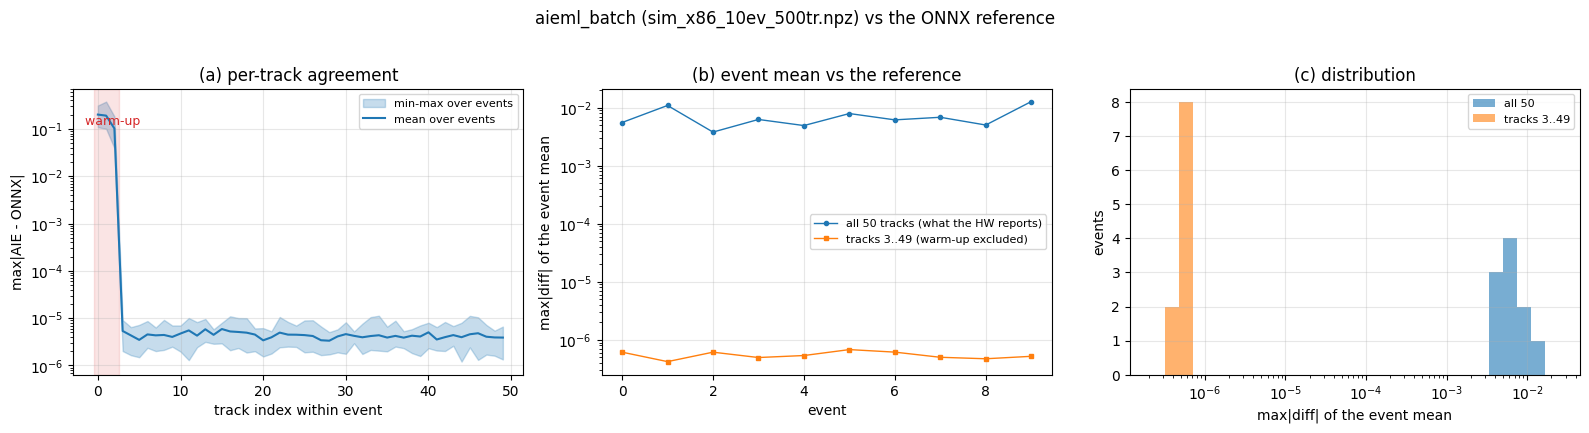

In [15]:
if HAVE_PER_TRACK:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

    # (a) error vs track index within the event
    mu, lo, hi = per_track_err.mean(0), per_track_err.min(0), per_track_err.max(0)
    ax[0].fill_between(range(TRACKS_PER_EVENT), lo, hi, alpha=.25, color='tab:blue',
                       label='min-max over events')
    ax[0].plot(mu, color='tab:blue', lw=1.5, label='mean over events')
    ax[0].axvspan(-0.5, WARMUP - 0.5, color='tab:red', alpha=.12)
    ax[0].text(WARMUP / 2, mu.max(), ' warm-up', color='tab:red', va='top', ha='center', fontsize=9)
    ax[0].set_yscale('log'); ax[0].set_xlabel('track index within event')
    ax[0].set_ylabel('max|AIE - ONNX|'); ax[0].set_title('(a) per-track agreement')
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

    # (b) event mean, both conventions
    ax[1].plot(m_all,  'o-', ms=3, lw=1, label=f'all {TRACKS_PER_EVENT} tracks (what the HW reports)')
    ax[1].plot(m_warm, 's-', ms=3, lw=1, label=f'tracks {WARMUP}..{TRACKS_PER_EVENT-1} (warm-up excluded)')
    ax[1].set_yscale('log'); ax[1].set_xlabel('event')
    ax[1].set_ylabel('max|diff| of the event mean')
    ax[1].set_title('(b) event mean vs the reference')
    ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

    # (c) distribution
    bins = np.logspace(np.log10(min(m_warm.min(), m_all.min()) / 2),
                       np.log10(m_all.max() * 2), 30)
    ax[2].hist(m_all,  bins=bins, alpha=.6, label=f'all {TRACKS_PER_EVENT}')
    ax[2].hist(m_warm, bins=bins, alpha=.6, label=f'tracks {WARMUP}..{TRACKS_PER_EVENT-1}')
    ax[2].set_xscale('log'); ax[2].set_xlabel('max|diff| of the event mean')
    ax[2].set_ylabel('events'); ax[2].set_title('(c) distribution')
    ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)

    fig.suptitle(f'aieml_batch ({SIM["file"]}) vs the ONNX reference', y=1.02)
    fig.tight_layout()
    fig.savefig(OUTD / 'warmup_analysis.png', dpi=140, bbox_inches='tight')
    plt.show()


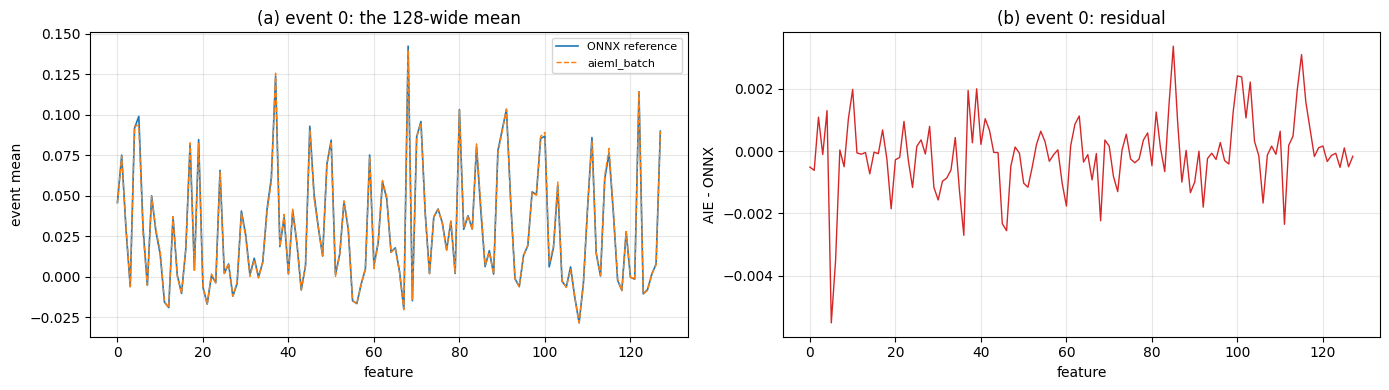

In [16]:
if SIM:
    # One event, element by element: does the AIE track the reference or merely sit near it?
    ev = 0
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(REF['mean'][ev], lw=1.2, label='ONNX reference')
    ax[0].plot(SIM['mean'][ev], lw=1.0, ls='--', label='aieml_batch')
    ax[0].set_xlabel('feature'); ax[0].set_ylabel('event mean')
    ax[0].set_title(f'(a) event {ev}: the 128-wide mean')
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

    ax[1].plot(SIM['mean'][ev] - REF['mean'][ev], lw=1, color='tab:red')
    ax[1].set_xlabel('feature'); ax[1].set_ylabel('AIE - ONNX')
    ax[1].set_title(f'(b) event {ev}: residual'); ax[1].grid(alpha=.3)
    fig.tight_layout()
    fig.savefig(OUTD / 'event0_residual.png', dpi=140, bbox_inches='tight')
    plt.show()


In [17]:
HW_DIR = None    # e.g. Path('/path/to/copied/results')

if HW_DIR and Path(HW_DIR).is_dir():
    files = sorted(Path(HW_DIR).glob('track_mean_128_ev*.txt'),
                   key=lambda p: int(''.join(c for c in p.stem if c.isdigit()) or 0))
    hw = np.stack([np.loadtxt(f) for f in files])
    n  = min(len(hw), N_EVENTS)
    e  = np.abs(hw[:n] - R10K['mean'][:n]).max(axis=1)
    print(f'{len(hw)} hardware event means from {HW_DIR}')
    print(f'  worst     : {e.max():.3e} (event {int(e.argmax())})')
    print(f'  median    : {np.median(e):.3e}')
    print(f'  over 1e-4 : {(e > 1e-4).sum()} of {n}')

    plt.figure(figsize=(9, 3.5))
    plt.plot(e, 'o-', ms=3, lw=1)
    plt.yscale('log'); plt.xlabel('event'); plt.ylabel('max|HW - ONNX|')
    plt.title('hardware event mean vs the ONNX reference'); plt.grid(alpha=.3)
    plt.tight_layout(); plt.show()
else:
    print('HW_DIR not set - see the cell above for how to produce the files.')


HW_DIR not set - see the cell above for how to produce the files.


In [18]:
hw_tracks = np.array([50, 500, 5000, 10000], float)
hw_us     = np.array([635., 900., 3480., 6578.])
MACS_PER_TRACK, II_NS, ITER_PER_EVENT = 264192, 4161.0, 7

A = np.vstack([np.ones_like(hw_tracks), hw_tracks]).T
(fixed, marginal), *_ = np.linalg.lstsq(A, hw_us, rcond=None)
model_us = II_NS * 1e-3 * ITER_PER_EVENT * np.ceil(hw_tracks / TRACKS_PER_EVENT)
cycle_ns = II_NS * ITER_PER_EVENT / TRACKS_PER_EVENT

print(f'fit: total = {fixed:.1f} us + {marginal*1000:.1f} ns x tracks')
print(f'cycle-accurate marginal: {cycle_ns:.1f} ns/track'
      f'   (fit is {100*abs(marginal*1000-cycle_ns)/cycle_ns:.1f}% off)\n')
print(f'{"tracks":>7} {"measured":>11} {"fit":>10} {"AIE model":>11} {"overhead":>9}'
      f' {"ns/track":>9} {"GOP/s":>8}')
for t, y, f, m in zip(hw_tracks, hw_us, A @ [fixed, marginal], model_us):
    print(f'{t:7.0f} {y:9.1f}us {f:8.1f}us {m:9.1f}us {100*(1-m/y):8.1f}%'
          f' {y/t*1000:9.1f} {2*MACS_PER_TRACK*t/(y*1e-6)/1e9:8.1f}')


fit: total = 583.0 us + 595.6 ns x tracks
cycle-accurate marginal: 582.5 ns/track   (fit is 2.2% off)

 tracks    measured        fit   AIE model  overhead  ns/track    GOP/s
     50     635.0us    612.8us      29.1us     95.4%   12700.0     41.6
    500     900.0us    880.8us     291.3us     67.6%    1800.0    293.5
   5000    3480.0us   3560.8us    2912.7us     16.3%     696.0    759.2
  10000    6578.0us   6538.7us    5825.4us     11.4%     657.8    803.3


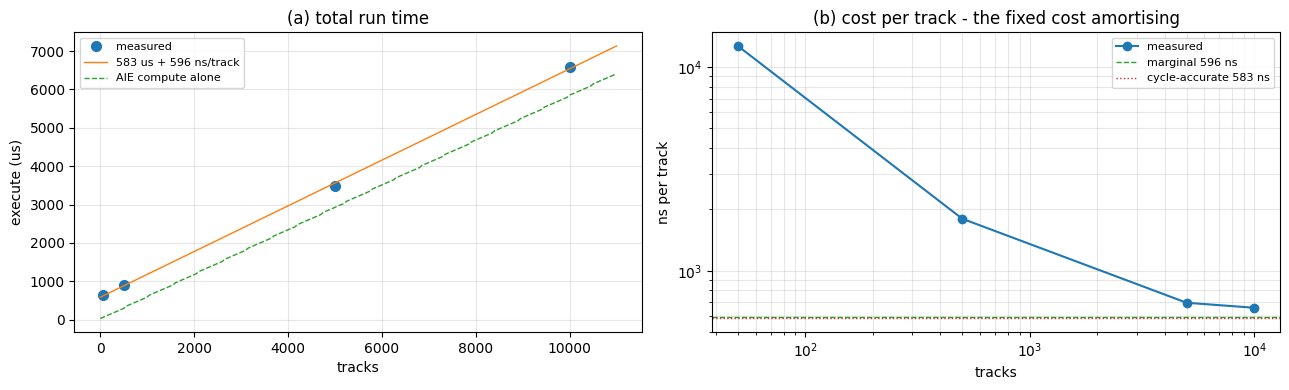

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
xs = np.linspace(0, hw_tracks.max() * 1.1, 200)

ax[0].plot(hw_tracks, hw_us, 'o', ms=7, label='measured')
ax[0].plot(xs, fixed + marginal * xs, '-', lw=1,
           label=f'{fixed:.0f} us + {marginal*1000:.0f} ns/track')
ax[0].plot(xs, II_NS*1e-3*ITER_PER_EVENT*np.ceil(np.maximum(xs, 1)/TRACKS_PER_EVENT), '--',
           lw=1, label='AIE compute alone')
ax[0].set_xlabel('tracks'); ax[0].set_ylabel('execute (us)')
ax[0].set_title('(a) total run time'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(hw_tracks, hw_us / hw_tracks * 1000, 'o-', ms=6, label='measured')
ax[1].axhline(marginal * 1000, ls='--', c='tab:green', lw=1,
              label=f'marginal {marginal*1000:.0f} ns')
ax[1].axhline(cycle_ns, ls=':', c='tab:red', lw=1, label=f'cycle-accurate {cycle_ns:.0f} ns')
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_xlabel('tracks'); ax[1].set_ylabel('ns per track')
ax[1].set_title('(b) cost per track - the fixed cost amortising')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which='both')

fig.tight_layout()
fig.savefig(OUTD / 'hw_performance.png', dpi=140, bbox_inches='tight')
plt.show()
